### Illustrate getting waveforms from v0 Spikesorting

In [32]:
from spyglass.spikesorting.v0.spikesorting_curation import (
    CuratedSpikeSorting,
    CuratedSpikeSortingSelection,
    Curation,
)

from spyglass.shijiegu.Analysis_SGU import RippleTimes

import numpy as np
import pandas as pd
import uuid
from pathlib import Path
from spyglass.settings import waveforms_dir
import spikeinterface as si

In [33]:
nwb_copy_file_name = 'eliot20221021_.nwb'
epoch_name = '08_Seq2Session4'

In [34]:
def findWaveForms(eletrode):
    key = {'nwb_file_name':nwb_copy_file_name,
           'sort_interval_name':epoch_name,
           'sort_group_id':eletrode,
           'artifact_removed_interval_list_name':
           f'eliot20221021_.nwb_08_Seq2Session4_{eletrode}_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only'}

    nwb_units = (CuratedSpikeSorting() & key).fetch_nwb()[0]["units"]

    recording = Curation.get_recording(key)
    if recording.get_num_segments() > 1:
        recording = si.concatenate_recordings([recording])
    sorting = Curation.get_curated_sorting(key)

    curation_id = (Curation & key).fetch1('curation_id')
    waveform_extractor_name = (
        f'{key["nwb_file_name"]}_{str(uuid.uuid4())[0:8]}_'
        f'{curation_id}_clusterless_waveforms'
    )
    waveform_extractor_path = str(
        Path(waveforms_dir) / Path(waveform_extractor_name)
    )

    WAVEFORM_PARAMS = {
    "ms_before": 0.5,
    "ms_after": 0.5,
    "max_spikes_per_unit": None,
    "n_jobs": 5,
    "total_memory": "5G",
    }
    waveform_extractor = si.extract_waveforms(
        recording=recording,
        sorting=sorting,
        folder=waveform_extractor_path,
        **WAVEFORM_PARAMS,
    )
    waveforms = waveform_extractor.get_waveforms(0)

    return nwb_units,waveforms

In [35]:
def RippleTime2Index(nwb_units,ripple_times,fragFlag = True):
    """filters spikes according to their time, whether cont/frag ripple times"""
    #### THIS IS HOW I GET SPIKE TIMES
    spike_times = nwb_units.spike_times[0]
    ####
    ind = []
        
    for ripple_id in ripple_times.index:
        if fragFlag:
            intervals = ripple_times.loc[ripple_id].frag_intvl
        else:
            intervals = ripple_times.loc[ripple_id].cont_intvl
        
        for interval in intervals:
            ind_subset=np.argwhere(
                np.logical_and(spike_times>=interval[0],spike_times<=interval[1])).ravel()
            ind.append(ind_subset)
    return np.concatenate(ind)

In [36]:
eletrodes = np.unique((CuratedSpikeSorting() & {'nwb_file_name':
                                    nwb_copy_file_name}).fetch('sort_group_id'))
electrode_plot = eletrodes#[5,20]

In [37]:
# extract waveform
nwb_units_all = {}
waveforms_all = {}
for e in electrode_plot:
    nwb_units_all[e],waveforms_all[e] = findWaveForms(e)

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

...

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

extract waveforms memmap:   0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
# filter spike times

In [38]:
ripple_times = pd.DataFrame((RippleTimes & 
                             {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': epoch_name}).fetch1('ripple_times'))

In [39]:
import matplotlib.pyplot as plt

In [43]:
clip_size*1/30000*1000

0.9333333333333333

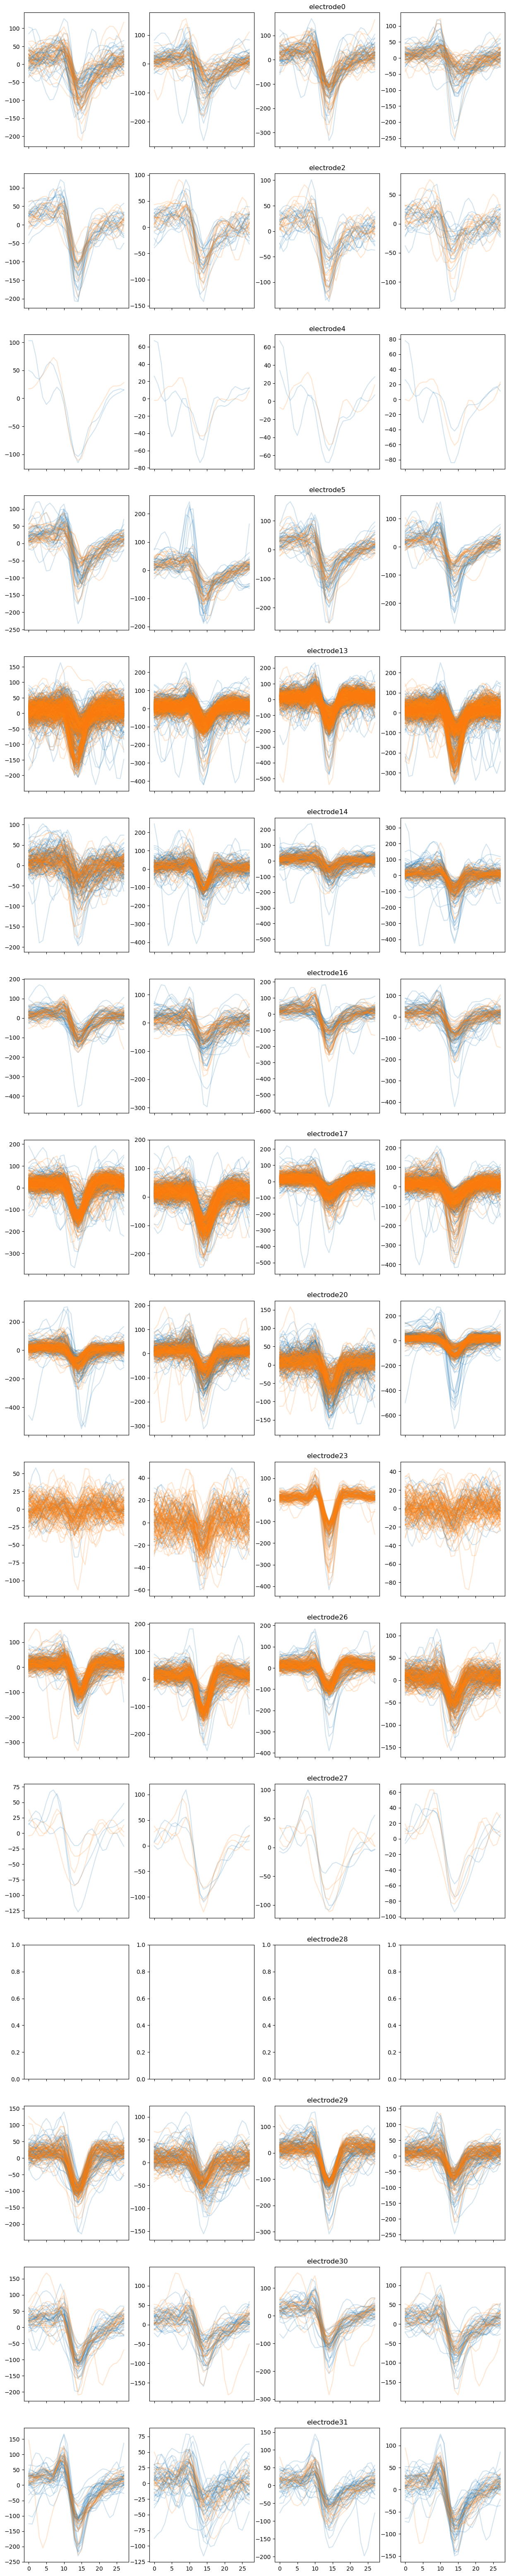

In [40]:
fig, axes = plt.subplots(len(electrode_plot),4,figsize = (15,5*len(electrode_plot)),sharex = 1)

row_ind = 0
for e in electrode_plot:
    (nwb_units,waveforms) = (nwb_units_all[e],waveforms_all[e])
    ind_frag = RippleTime2Index(nwb_units,ripple_times,fragFlag = True)
    ind_cont = RippleTime2Index(nwb_units,ripple_times,fragFlag = False)

    (sample_num,clip_size,channel_num) = waveforms.shape
    
    for s_ind in range(0,len(ind_frag),10):
        s = ind_frag[s_ind]
        for ch in range(channel_num):
            axes[row_ind,ch].plot(waveforms[s,:,ch].squeeze(),'C0',alpha = 0.2)
    
    for s_ind in range(0,len(ind_cont),10):
        s = ind_cont[s_ind]
        for ch in range(channel_num):
            axes[row_ind,ch].plot(waveforms[s,:,ch].squeeze(),'C1',alpha = 0.2)
    axes[row_ind,2].set_title('electrode'+str(e))
    row_ind = row_ind + 1
    
